# 加载数据

In [1]:
import mne
import numpy as np
import os
from pathlib import Path

# 1. 设定数据路径 (请确认路径是否正确)
data_dir = Path('/Volumes/TPU301-256/QQ/EEGraw/Preprocessed/')

# 2. 自动寻找所有以 _epo.fif 结尾的文件
# 假设文件名格式是 "2101_epo.fif", "2102_epo.fif" ...
# 2. 自动寻找所有以 _epo.fif 结尾的文件
# 关键修改：用列表推导式过滤掉以 '._' 开头的隐藏文件
files = sorted([f for f in data_dir.glob('*_epo.fif') if not f.name.startswith('._')])

print(f"找到 {len(files)} 个真实被试文件 (已剔除 macOS 隐藏文件)")

# 3. 循环加载并计算平均 (Evoked)
all_evokeds = []
subjects_list = []

for file in files:
    subj_id = file.stem.split('_')[0] # 提取 '2101'
    print(f"Loading {subj_id}...", end='\r')
    
    # 读取 Epochs
    epochs = mne.read_epochs(file, preload=True, verbose=False)
    
    # 简单的基线校正 (如果有必要再次确认)
    epochs.apply_baseline((-0.2, 0))
    
    # 计算该被试的平均诱发电位 (不分条件，所有试次平均)
    # 这一步会极大地压缩数据量，把几百兆变成几百 K
    evoked = epochs.average()
    
    # 存入列表
    all_evokeds.append(evoked)
    subjects_list.append(subj_id)

print(f"\n成功加载 {len(all_evokeds)} 位被试的平均数据。")

找到 36 个真实被试文件 (已剔除 macOS 隐藏文件)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
App

# 计算绘制Grand Average确定波形

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 53 sensor positions
Interpolating 10 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 61 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 54 sensor positions
Interpolating 9 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 61 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm

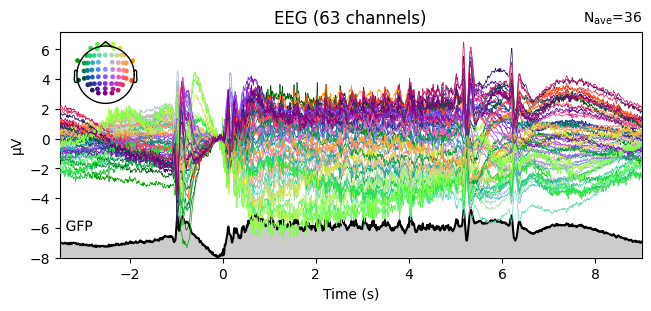

No projector specified for this dataset. Please consider the method self.add_proj.


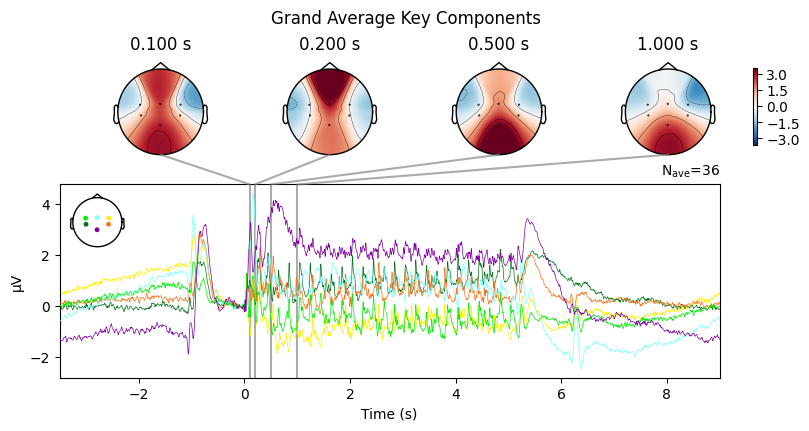

In [2]:
# 1. 计算 Grand Average (N=29 的平均)
grand_average = mne.grand_average(all_evokeds)

# 2. 画全脑平均波形 (Butterfly Plot)
# 这一步能看到是否有全脑一致的诱发反应
grand_average.plot(gfp=True, spatial_colors=True, window_title="Grand Average (N=29)")

# 3. 画关键感兴趣区 (ROI) 的波形
# 你的实验是体感刺激，重点看 C3, C4, Cz, CP3, CP4
roi_channels = ['C3', 'C4', 'Cz', 'CP3', 'CP4', 'Cpz', 'Pz']
# 确保通道存在
picks = [ch for ch in roi_channels if ch in grand_average.ch_names]

fig = grand_average.plot_joint(times=[0.1, 0.2, 0.5, 1.0], title="Grand Average Key Components", picks=picks)

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 53 sensor positions
Interpolating 10 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 61 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 54 sensor positions
Interpolating 9 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 61 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm

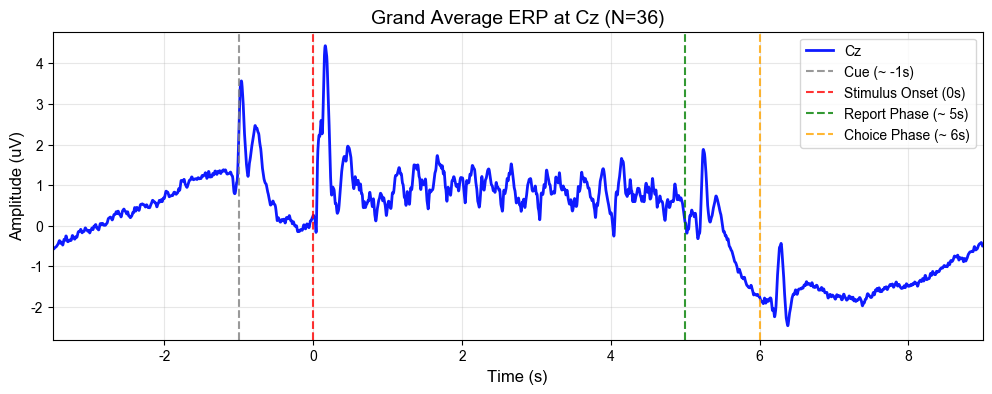

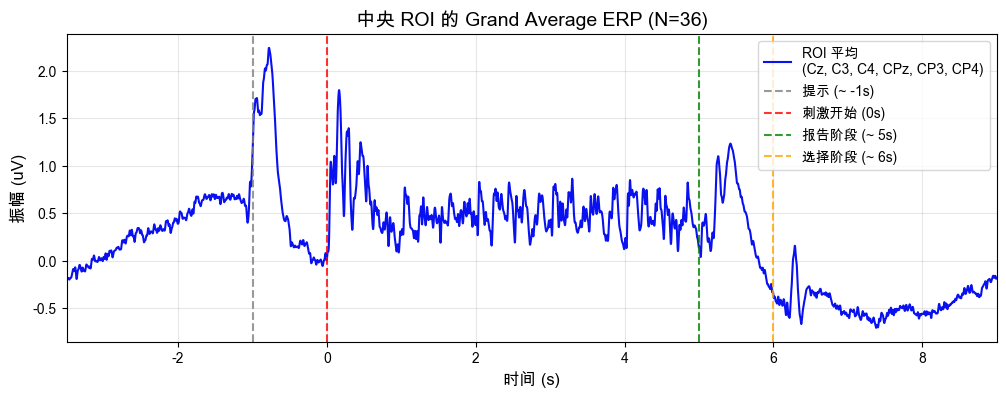

In [3]:
# 1. 计算 Grand Average (动态获取加载的被试数量)
grand_average = mne.grand_average(all_evokeds)
n_subjects = len(all_evokeds)

# 我们这里专门提取出体感反应最强的中央区 (如 Cz 或 ROI平均) 来画。
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# 解决 macOS 下中文显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 挑选体感核心区域通道
roi_channels = ['Cz', 'C3', 'C4', 'CPz', 'CP3', 'CP4']
picks = [ch for ch in roi_channels if ch in grand_average.ch_names]

# ============== 方法一：画单个最具代表性的电极 (如 Cz) ==============
plt.figure(figsize=(12, 4))
cz_data = grand_average.copy().pick('Cz').data[0] * 1e6  # 转换成微伏
times = grand_average.times

plt.plot(times, cz_data, c="#0e1aff", linewidth=2, label='Cz')

plt.title(f"Grand Average ERP at Cz (N={n_subjects})", fontsize=14)

# 【新增】添加各个阶段的时间点标记
plt.axvline(-1, color='gray', linestyle='--', alpha=0.8, label='Cue (~ -1s)')
plt.axvline(0, color='red', linestyle='--', alpha=0.8, label='Stimulus Onset (0s)')
plt.axvline(5, color='green', linestyle='--', alpha=0.8, label='Report Phase (~ 5s)')
plt.axvline(6, color='orange', linestyle='--', alpha=0.8, label='Choice Phase (~ 6s)')

plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Amplitude (uV)", fontsize=12)
plt.xlim(times[0], times[-1]) # 覆盖整个 12 试次长度
plt.legend(loc='upper right', fontsize=10) # 为了不挡住后半段的波形，把图例调整到左下角
plt.grid(True, alpha=0.3)
plt.show()

# ============== 方法二：画整个 ROI 区域的平均值 (更平滑，科学界常用) ==============
# 把这几个中心通道的数据按列求平均，融合成一条更加稳定的超级平均线
roi_evoked = grand_average.copy().pick(picks)
roi_data_mean = roi_evoked.data.mean(axis=0) * 1e6  # (n_times,)

plt.figure(figsize=(12, 4))
#1. 计算 Grand Average (动态获取加载的被试数量)
plt.plot(times, roi_data_mean, c="#0911F0", linewidth=1.5, 
         label=f'ROI 平均\n(Cz, C3, C4, CPz, CP3, CP4)')

plt.title(f"中央 ROI 的 Grand Average ERP (N={n_subjects})", fontsize=14)

# 【新增】添加各个阶段的时间点标记
plt.axvline(-1, color='gray', linestyle='--', alpha=0.8, label='提示 (~ -1s)')
plt.axvline(0, color='red', linestyle='--', alpha=0.8, label='刺激开始 (0s)')
plt.axvline(5, color='green', linestyle='--', alpha=0.8, label='报告阶段 (~ 5s)')
plt.axvline(6, color='orange', linestyle='--', alpha=0.8, label='选择阶段 (~ 6s)')

plt.xlabel("时间 (s)", fontsize=12)
plt.ylabel("振幅 (uV)", fontsize=12)
plt.xlim(times[0], times[-1]) 
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# 第一步：二次滤波，低通位30Hz

In [4]:
# -------------------------------------------------------------
# 1. 预处理：低通滤波 (30Hz) 以获得平滑的 ERP 和 Topomap
# -------------------------------------------------------------
print("Applying Low-pass filter (30Hz) to all subjects...")
# 使用 mne.filter.filter_data 对 evoked 数据进行滤波
# 注意：直接修改 all_evokeds 里的对象
for evo in all_evokeds:
    evo.filter(l_freq=None, h_freq=30.0, verbose=False)

# -------------------------------------------------------------
# 2. 重新计算 Grand Average (基于滤波后的数据)
# -------------------------------------------------------------
grand_average = mne.grand_average(all_evokeds)

# -------------------------------------------------------------
# 3. 重新运行你刚才的 Topomap 和 打印 Top 5 代码
# -------------------------------------------------------------
# (把你刚才的那段 Cell 代码再运行一遍，或者复制到这里)
# ...

Applying Low-pass filter (30Hz) to all subjects...
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 53 sensor positions
Interpolating 10 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 61 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 54 sensor positions
Interpolating 9 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 61 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channel

# 第二步：全脑全通道Grand Average ERP和Cz全时间段的图形

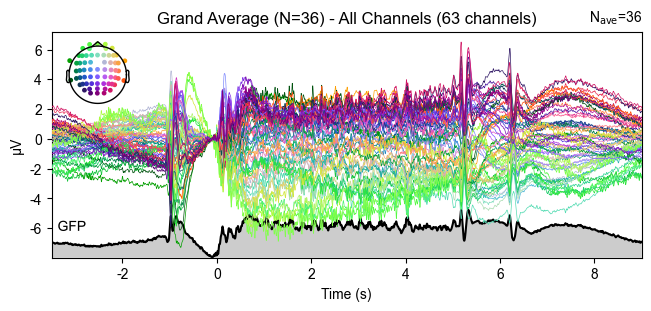

In [28]:
# -------------------------------------------------------------
# 1. 标准全脑蝴蝶图 (Grand Average across all channels)
# -------------------------------------------------------------
# gfp=True 会在底部画一条绿色的线，代表所有电极的标准差(即“全脑总功率”)，
# 峰值最高的地方就是大脑反应最剧烈的时候。

fig = grand_average.plot(
    gfp=True,              # 显示全球场功率 (Global Field Power)
    spatial_colors=True,   # 根据电极位置自动着色 (左脑/右脑/前/后颜色不同)
    window_title="Grand Average Butterfly Plot",
    titles={"eeg": "Grand Average (N=36) - All Channels"},
    time_unit='s'
)
# 注意：这张图不需要 plt.show()，mne 会自动弹窗，但如果是 notebook内嵌模式，可能需要。

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 53 sensor positions
Interpolating 10 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 61 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 54 sensor positions
Interpolating 9 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm
Computing interpolation matrix from 61 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.9 mm

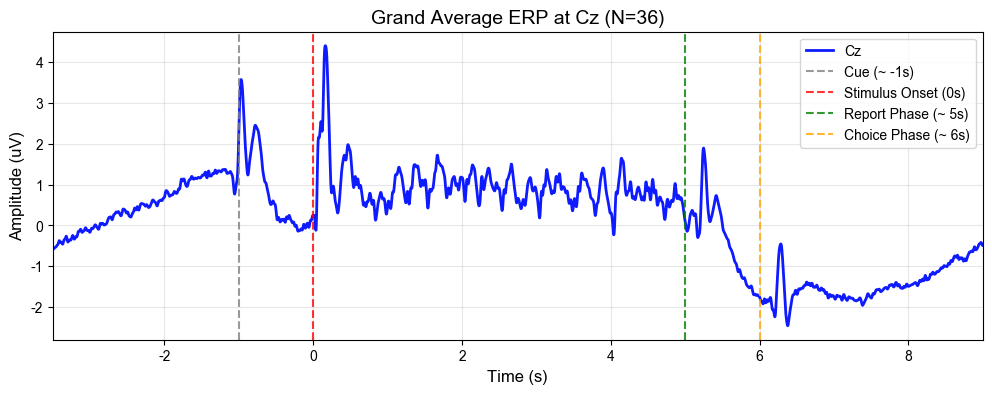

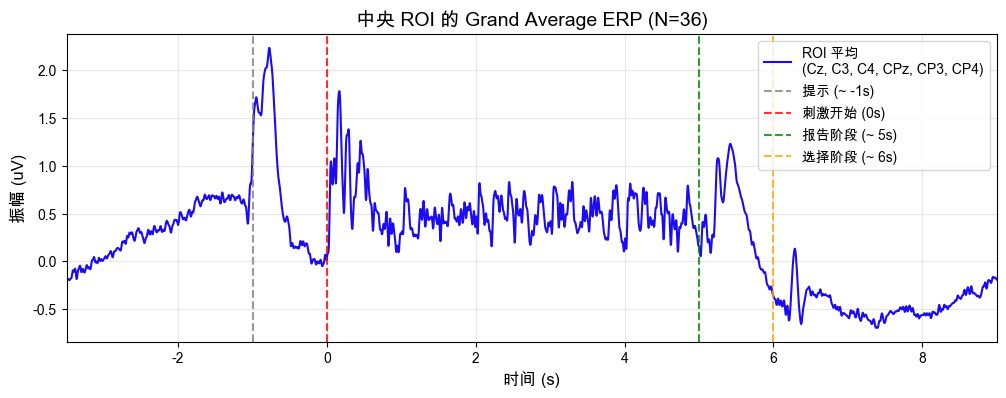

In [5]:
# 1. 计算 Grand Average (动态获取加载的被试数量)
grand_average = mne.grand_average(all_evokeds)
n_subjects = len(all_evokeds)

# 我们这里专门提取出体感反应最强的中央区 (如 Cz 或 ROI平均) 来画。
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# 解决 macOS 下中文显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 挑选体感核心区域通道
roi_channels = ['Cz', 'C3', 'C4', 'CPz', 'CP3', 'CP4']
picks = [ch for ch in roi_channels if ch in grand_average.ch_names]

# ============== 方法一：画单个最具代表性的电极 (如 Cz) ==============
plt.figure(figsize=(12, 4))
cz_data = grand_average.copy().pick('Cz').data[0] * 1e6  # 转换成微伏
times = grand_average.times

plt.plot(times, cz_data, c="#0e1aff", linewidth=2, label='Cz')

plt.title(f"Grand Average ERP at Cz (N={n_subjects})", fontsize=14)

# 【新增】添加各个阶段的时间点标记
plt.axvline(-1, color='gray', linestyle='--', alpha=0.8, label='Cue (~ -1s)')
plt.axvline(0, color='red', linestyle='--', alpha=0.8, label='Stimulus Onset (0s)')
plt.axvline(5, color='green', linestyle='--', alpha=0.8, label='Report Phase (~ 5s)')
plt.axvline(6, color='orange', linestyle='--', alpha=0.8, label='Choice Phase (~ 6s)')

plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Amplitude (uV)", fontsize=12)
plt.xlim(times[0], times[-1]) # 覆盖整个 12 试次长度
plt.legend(loc='upper right', fontsize=10) # 为了不挡住后半段的波形，把图例调整到左下角
plt.grid(True, alpha=0.3)
plt.show()

# ============== 方法二：画整个 ROI 区域的平均值 (更平滑，科学界常用) ==============
# 把这几个中心通道的数据按列求平均，融合成一条更加稳定的超级平均线
roi_evoked = grand_average.copy().pick(picks)
roi_data_mean = roi_evoked.data.mean(axis=0) * 1e6  # (n_times,)

plt.figure(figsize=(12, 4))
#1. 计算 Grand Average (动态获取加载的被试数量)
plt.plot(times, roi_data_mean, c="#1b0cf3", linewidth=1.5, 
         label=f'ROI 平均\n(Cz, C3, C4, CPz, CP3, CP4)')

plt.title(f"中央 ROI 的 Grand Average ERP (N={n_subjects})", fontsize=14)

# 【新增】添加各个阶段的时间点标记
plt.axvline(-1, color='gray', linestyle='--', alpha=0.8, label='提示 (~ -1s)')
plt.axvline(0, color='red', linestyle='--', alpha=0.8, label='刺激开始 (0s)')
plt.axvline(5, color='green', linestyle='--', alpha=0.8, label='报告阶段 (~ 5s)')
plt.axvline(6, color='orange', linestyle='--', alpha=0.8, label='选择阶段 (~ 6s)')

plt.xlabel("时间 (s)", fontsize=12)
plt.ylabel("振幅 (uV)", fontsize=12)
plt.xlim(times[0], times[-1]) 
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# ERP成分图

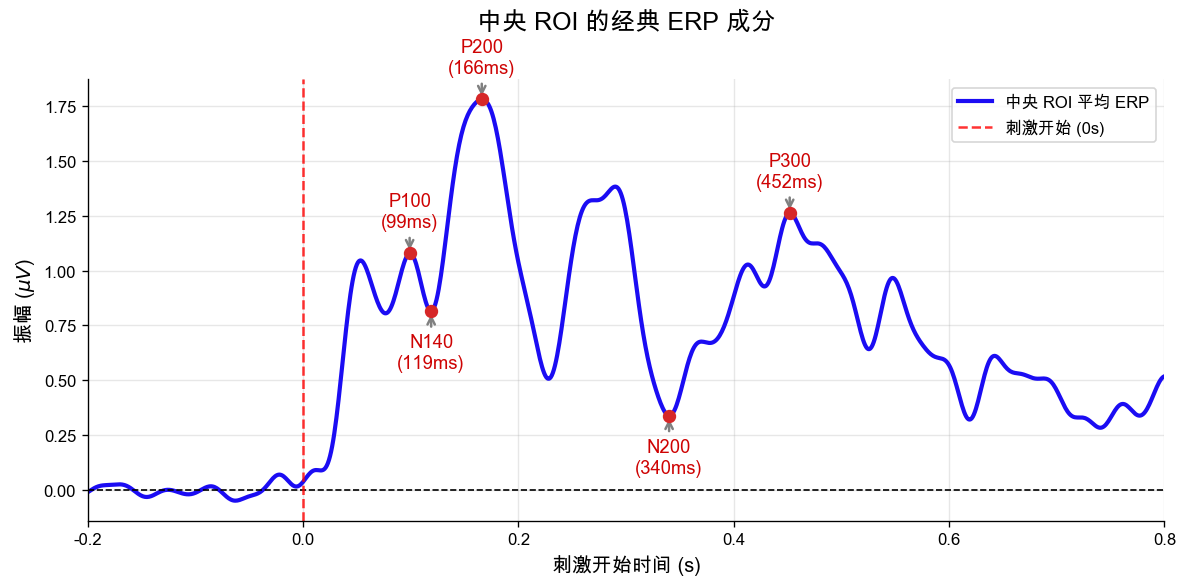

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 提取刺激发生前后的典型 ERP 时间窗 (-0.2s 到 +0.8s)
# ==========================================================
# 提取之前定义好的 ROI (Cz, C3, C4, CPz, CP3, CP4) 
roi_evoked = grand_average.copy().pick(picks).crop(tmin=-0.2, tmax=0.8)

times_erp = roi_evoked.times
# 对 ROI 通道取平均并转转换为微伏
erp_data = roi_evoked.data.mean(axis=0) * 1e6  

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

# 画主波形
ax.plot(times_erp, erp_data, color="#1b0cf3", linewidth=2.5, label="中央 ROI 平均 ERP")
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.8, label="刺激开始 (0s)")

# ==========================================================
# 定义经典 ERP 成分的时间搜索窗口 (可以根据你的波形手动微调时间窗)
# 格式: "成分名称": (开始时间s, 结束时间s, '极值类型')
# ==========================================================
components = {
    "P100": (0.07, 0.12, 'max'),  # 感觉诱发的早期成分
    "N140": (0.11, 0.15, 'min'),  # 体感诱发(SEP)典型的负波
    "P200": (0.14, 0.24, 'max'),  # 认知加工的开始
    "N200": (0.28, 0.35, 'min'),  # 冲突控制或刺激识别
    "P300": (0.35, 0.65, 'max')   # 大脑高级认知、工作记忆更新 (最著名的波)
}

# 自动寻找极值并打上标签
for name, (t_start, t_end, peak_type) in components.items():
    # 截取该时间窗
    mask = (times_erp >= t_start) & (times_erp <= t_end)
    if not np.any(mask): continue
    
    window_times = times_erp[mask]
    window_data = erp_data[mask]
    
    # 找极大值或极小值
    idx = np.argmax(window_data) if peak_type == 'max' else np.argmin(window_data)
        
    peak_t = window_times[idx]
    peak_v = window_data[idx]
    
    # 在图上画红色定位点
    ax.plot(peak_t, peak_v, 'o', color='#d62728', markersize=7, zorder=5)
    
    # 加文字标注和箭头 (正波字放上面，负波字放下面)
    offset_y = 25 if peak_type == 'max' else -25
    ax.annotate(f"{name}\n({peak_t*1000:.0f}ms)", 
                xy=(peak_t, peak_v), xytext=(0, offset_y), textcoords='offset points',
                ha='center', va='center', fontweight='bold', color='#CE0303', fontsize=11,
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# 装饰器
ax.set_title("中央 ROI 的经典 ERP 成分", fontsize=15, pad=30)
ax.set_xlabel("刺激开始时间 (s)", fontsize=12)
ax.set_ylabel(r"振幅 ($\mu V$)", fontsize=12)
ax.set_xlim(-0.2, 0.8)

# 坐标轴美化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 第三步：全频段平均PSD和区域PSD

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).


/opt/miniconda3/envs/mne_env/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


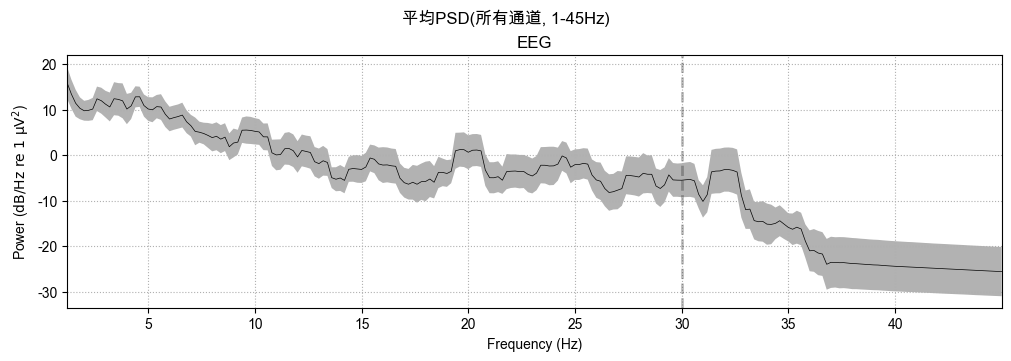

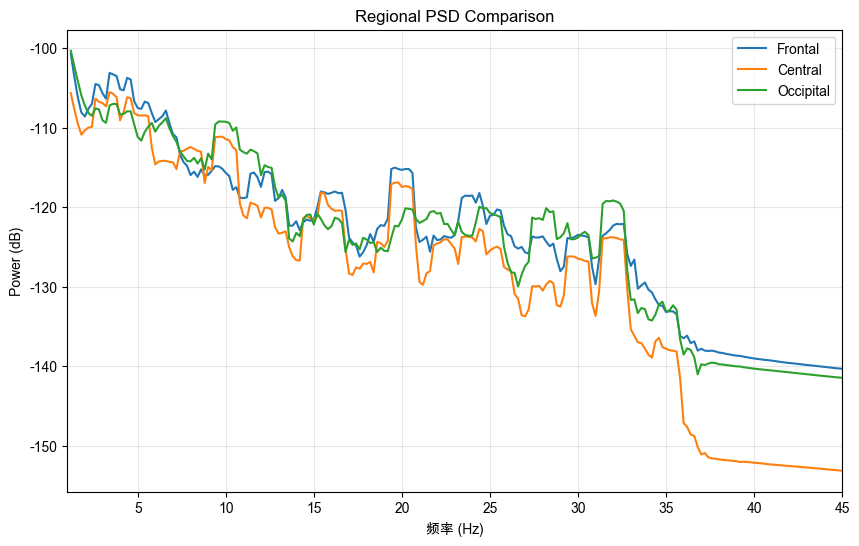

In [9]:
# -------------------------------------------------------------
# 3. 全局频域特征 (Grand Average PSD - Full Spectrum)
# -------------------------------------------------------------
# 目的：展示实验全程的脑电频域分布，确认信号质量和典型节律。

# 这次我们看全频段 (1 - 45 Hz)
# 涵盖 Delta(1-4), Theta(4-8), Alpha(8-13), Beta(13-30), Gamma(30+)

# 计算 PSD (使用 Multitaper 获得平滑曲线)
psd_all = grand_average.compute_psd(
    method='multitaper', 
    fmin=1.0, fmax=45.0,
    tmin=0, tmax=5.0  # 取刺激阶段
)

# 1. 总体平均图 (All Channels)
fig1 = psd_all.plot(
    average=True, 
    spatial_colors=False, 
    dB=True, 
    picks='eeg'
)
fig1.suptitle("平均PSD(所有通道, 1-45Hz)")

# 2. 分区域展示 (Regional PSD)
# 我们可以对比一下 前额(Frontal) vs 中央(Central) vs 枕叶(Occipital)
# 看不同脑区的 Alpha 波和 SSSEP 是不是不一样
roi_dict = {
    'Frontal': ['Fz', 'F3', 'F4'],
    'Central': ['Cz', 'C3', 'C4'],      #SSSEP 应该在这里
    'Occipital': ['Oz', 'O1', 'O2']     #视觉 Alpha 应该在这里
}

# 过滤掉不存在的通道
valid_rois = {k: [ch for ch in v if ch in grand_average.ch_names] for k, v in roi_dict.items()}

plt.figure(figsize=(10, 6))
freqs = psd_all.freqs

for label, channels in valid_rois.items():
    if channels:
        # 获取该 ROI 的平均 PSD 数据
        # get_data 返回 (n_channels, n_freqs)，我们求平均 -> (n_freqs,)
        roi_data = psd_all.get_data(picks=channels).mean(axis=0)
        # 转换为 dB
        roi_data_db = 10 * np.log10(roi_data)
        plt.plot(freqs, roi_data_db, label=label)

plt.title("Regional PSD Comparison")
plt.xlabel("频率 (Hz)")
plt.ylabel("Power (dB)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1, 45)
plt.show()

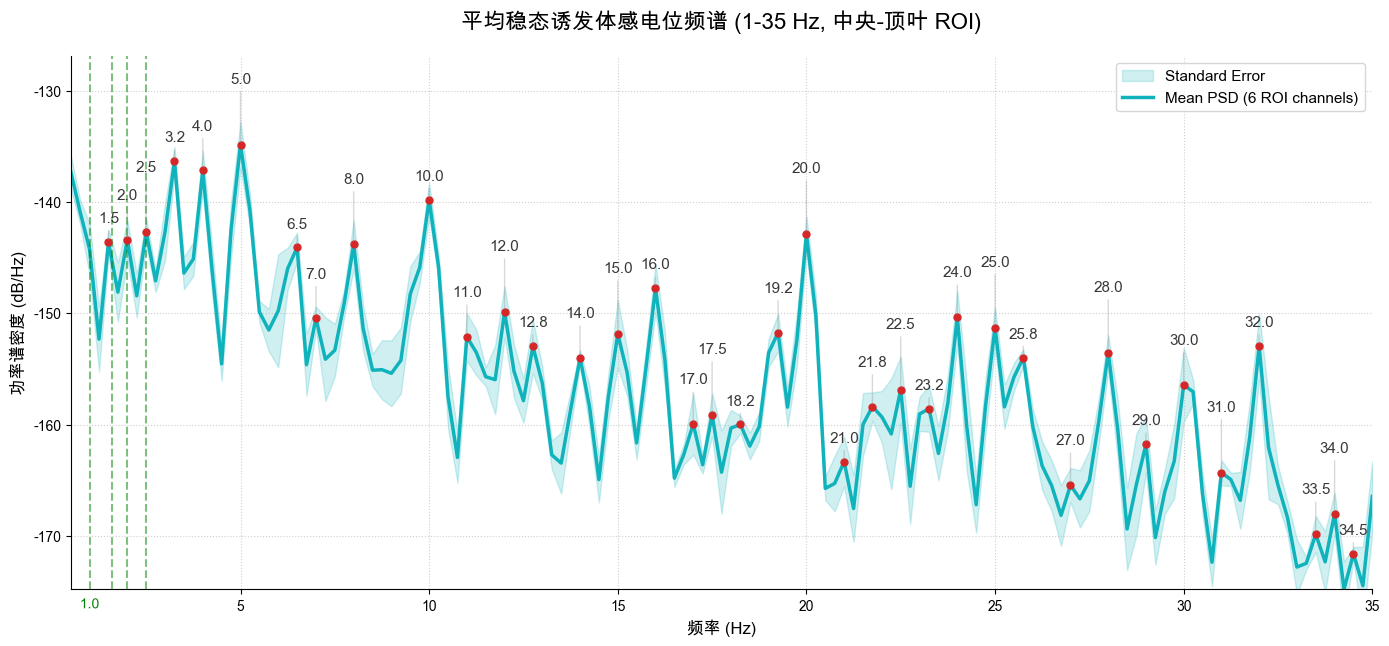

In [11]:
# -------------------------------------------------------------
# 3. 最终严谨版：先转 dB 后平均 (Standard Scientific Approach)
# -------------------------------------------------------------
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import matplotlib.patheffects as pe
import numpy as np

# 设置全局字体
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# 解决 macOS 下中文显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 计算 PSD (Welch)
n_fft = int(4.0 * grand_average.info['sfreq']) 
roi_picks = ['Cz', 'C3', 'C4', 'CP3', 'CP4', 'CPz'] 
valid_picks = [ch for ch in roi_picks if ch in grand_average.ch_names]

psd_full = grand_average.compute_psd(
    method='welch',
    picks=valid_picks,
    fmin=0.5, fmax=35.0, 
    tmin=0.0, tmax=5.0,
    n_fft=n_fft,
    verbose=False
)

# 2. 准备数据 (Correct Order: Power -> dB -> Mean/SEM)
psd_data, freqs = psd_full.get_data(return_freqs=True) 

# 第一步：先对每个通道/被试的数据转 dB
# 这一步让数据分布正态化，减少离群值影响
psd_data_db = 10 * np.log10(psd_data)

# 第二步：在 dB 域上求统计量
mean_psd_db = np.mean(psd_data_db, axis=0) # 算术平均
std_psd_db = np.std(psd_data_db, axis=0)   # 标准差
sem_psd_db = std_psd_db / np.sqrt(psd_data.shape[0]) # 标准误

# 3. 绘图
fig, ax = plt.subplots(figsize=(14, 7))

# --- 画阴影 (SEM) ---
# 这里的含义是：我们在 dB 域上有 68% 的信心均值落在阴影里
ax.fill_between(freqs, mean_psd_db - sem_psd_db, mean_psd_db + sem_psd_db, 
                 color='#10B3BC', alpha=0.2, label='Standard Error')

# --- 画主曲线 ---
ax.plot(freqs, mean_psd_db, color="#10B3BC", linewidth=2.5, 
        label=f'Mean PSD ({len(valid_picks)} ROI channels)')

# --- 绿色虚线 + X轴清晰标注 (只标 1.0Hz) ---
target_freqs = [1.0, 1.6, 2.0, 2.5]
y_min, y_max = np.min(mean_psd_db), np.max(mean_psd_db)

for tf in target_freqs:
    ax.axvline(tf, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
    if tf == 1.0:
        ax.text(tf, -0.015, f"{tf}", color='green', ha='center', va='top', 
                transform=ax.get_xaxis_transform(), fontsize=10, fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])

# --- 红色波峰 ---
peaks, _ = find_peaks(mean_psd_db, height=y_min, prominence=0.2, distance=int(0.5 / (freqs[1]-freqs[0])))

for i, peak_idx in enumerate(peaks):
    peak_freq = freqs[peak_idx]
    peak_power = mean_psd_db[peak_idx]
    
    ax.plot(peak_freq, peak_power, "o", color='#d62728', markersize=5)
    
    offset = 12 + (i % 3) * 15  
    ax.annotate(f"{peak_freq:.1f}", 
                xy=(peak_freq, peak_power), 
                xytext=(0, offset), textcoords='offset points',
                ha='center', va='bottom', fontsize=11, color="#393737", fontweight='bold',
                arrowprops=dict(arrowstyle="-", color='gray', alpha=0.3))

# 装饰
ax.set_title("平均稳态诱发体感电位频谱 (1-35 Hz, 中央-顶叶 ROI)", fontsize=16, pad=20)
ax.set_xlabel("频率 (Hz)", fontsize=12)
ax.set_ylabel("功率谱密度 (dB/Hz)", fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, which='both', linestyle=':', alpha=0.6)

# 去掉多余边框 (SCI Style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(0.5, 35)
ax.set_ylim(y_min, y_max + (y_max-y_min)*0.2) 

plt.tight_layout()
plt.subplots_adjust(bottom=0.15) 
plt.show()

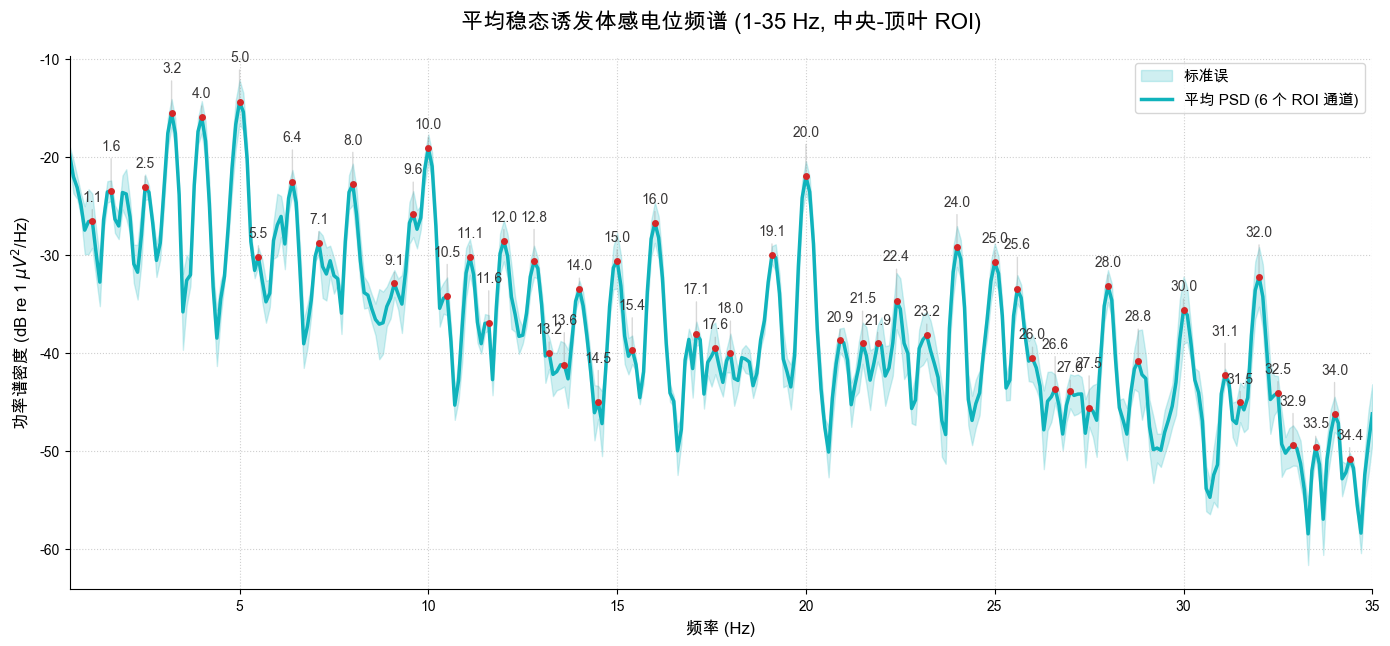

In [15]:
# -------------------------------------------------------------
# 3. 最终完美版：高分辨率 + 微伏单位 (High Res + uV scaling)
# -------------------------------------------------------------
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import matplotlib.patheffects as pe
import numpy as np

# 设置全局字体
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# 解决 macOS 下中文显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 计算 PSD (Welch)
# n_fft = 10s 补零，以获得 0.1Hz 的高频率分辨率，从而看到 1.6Hz
n_fft = int(10.0 * grand_average.info['sfreq']) 
roi_picks = ['Cz', 'C3', 'C4', 'CP3', 'CP4', 'CPz'] 
valid_picks = [ch for ch in roi_picks if ch in grand_average.ch_names]

psd_full = grand_average.compute_psd(
    method='welch',
    picks=valid_picks,
    fmin=0.5, fmax=35.0, 
    tmin=0.0, tmax=5.0,
    n_fft=n_fft,
    n_per_seg=int(5.0 * grand_average.info['sfreq']), # 实际数据段
    verbose=False
)

# 2. 准备数据 (单位转换 V -> uV)
psd_data, freqs = psd_full.get_data(return_freqs=True) 

# --- 关键修改：将单位从 V^2/Hz 转换为 uV^2/Hz ---
# 1 V = 1e6 uV => Power 倍数是 (1e6)^2 = 1e12
psd_data_uv = psd_data * 1e12 

# 第一步：先对每个通道/被试的数据转 dB
# 10 * log10(uV^2/Hz)
psd_data_db = 10 * np.log10(psd_data_uv)

# 第二步：在 dB 域上求统计量
mean_psd_db = np.mean(psd_data_db, axis=0) 
std_psd_db = np.std(psd_data_db, axis=0)
sem_psd_db = std_psd_db / np.sqrt(psd_data.shape[0])

# 3. 绘图
fig, ax = plt.subplots(figsize=(14, 7))

# --- 画阴影 (SEM) ---
ax.fill_between(freqs, mean_psd_db - sem_psd_db, mean_psd_db + sem_psd_db, 
                 color='#10B3BC', alpha=0.2, label='标准误')

# --- 画主曲线 ---
ax.plot(freqs, mean_psd_db, color="#10B3BC", linewidth=2.5, 
        label=f'平均 PSD ({len(valid_picks)} 个 ROI 通道)')

# --- 绿色虚线 (去掉底部的绿色数字) ---
target_freqs = [1.0, 1.6, 2.0, 2.5]
y_min, y_max = np.min(mean_psd_db), np.max(mean_psd_db)

# for tf in target_freqs:
    # ax.axvline(tf, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
    # 此处已移除 ax.text(...) 代码

# --- 红色波峰 (标注所有识别到的峰值) ---
# prominence: 突起程度，设小一点(0.1 或 0.2)可以抓到更多小峰
# distance: 峰间距，设为 4个点 (0.4Hz) 避免标太密
peaks, _ = find_peaks(mean_psd_db, height=y_min, prominence=0.2, distance=4)

for i, peak_idx in enumerate(peaks):
    peak_freq = freqs[peak_idx]
    peak_power = mean_psd_db[peak_idx]
    
    # 策略：直接在该点画红点并标数值
    ax.plot(peak_freq, peak_power, "o", color='#d62728', markersize=4)
    
    # 标注数值 (不再做任何筛选，所有峰都标)
    offset = 12 + (i % 2) * 15  # 简单的上下错开，防止重叠
    ax.annotate(f"{peak_freq:.1f}", 
                xy=(peak_freq, peak_power), 
                xytext=(0, offset), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color="#393737", fontweight='bold',
                arrowprops=dict(arrowstyle="-", color='gray', alpha=0.3))

# 装饰
ax.set_title("平均稳态诱发体感电位频谱 (1-35 Hz, 中央-顶叶 ROI)", fontsize=16, pad=20)
ax.set_xlabel("频率 (Hz)", fontsize=12)
# 单位这下就对了：dB relative to 1 (uV)^2/Hz
ax.set_ylabel(r"功率谱密度 (dB re 1 $\mu V^2$/Hz)", fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, which='both', linestyle=':', alpha=0.6)

# SCI Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0.5, 35)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15) 
plt.show()

# 第四步：体感区域SNR

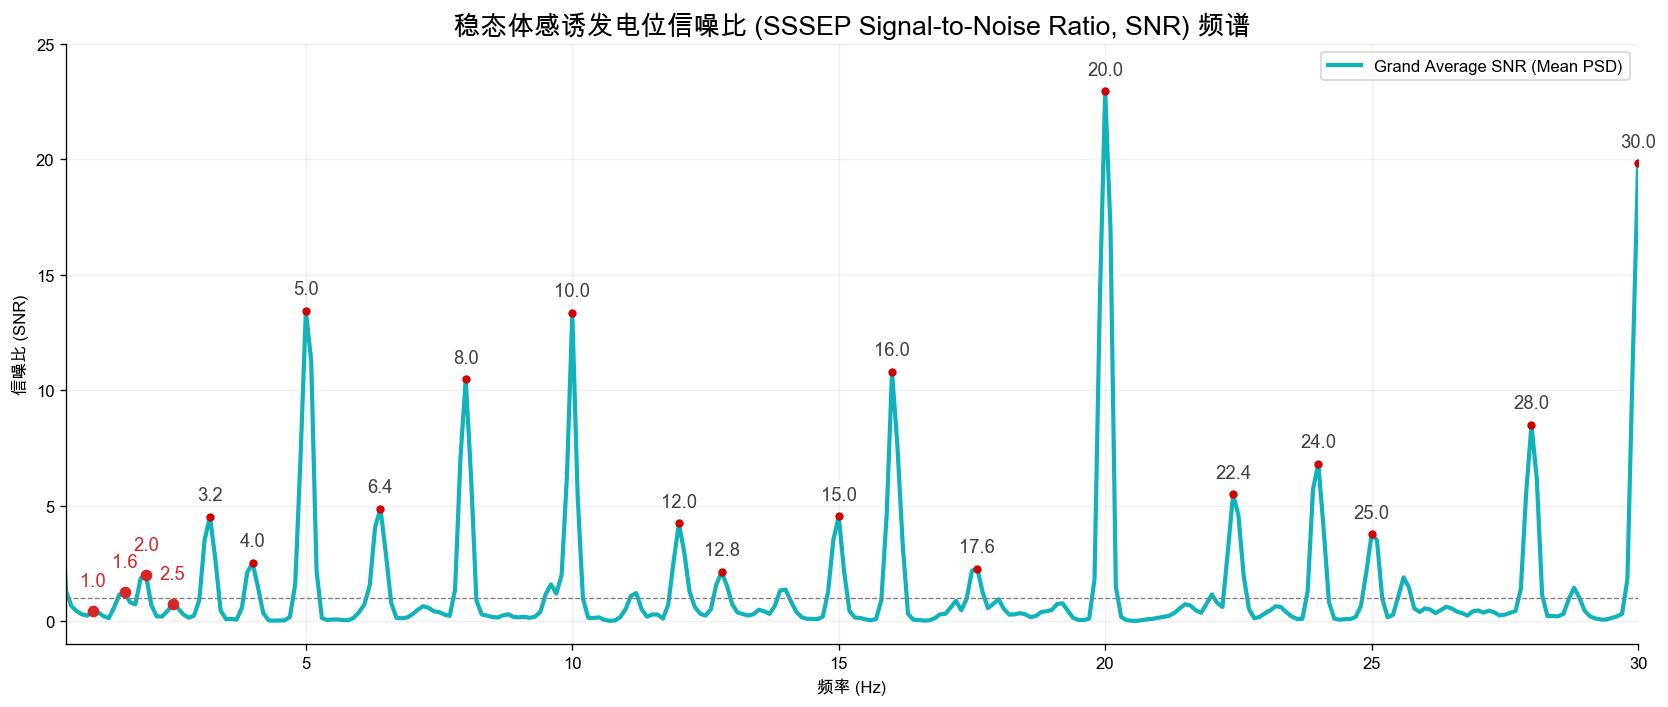

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 解决 macOS 下中文显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ================= 1. 核心修正：只选 ROI 通道 =================
# 去掉 Pz
roi_picks = ['Cz', 'C3', 'C4', 'CP3', 'CP4', 'CPz'] 
valid_picks = [ch for ch in roi_picks if ch in grand_average.ch_names]

# 1.1 设置高分辨率参数 (0.1Hz)
sfreq = 1000.0  
duration = 5.0
n_fft = int(sfreq / 0.1)
n_per_seg = int(sfreq * duration) 

# 1.2 计算 ROI 的 Grand Average PSD
psd_obj = grand_average.compute_psd(
    method='welch', 
    fmin=0.2, fmax=35.0,
    tmin=0, tmax=duration,
    n_fft=n_fft, 
    n_per_seg=n_per_seg,
    picks=valid_picks,
    verbose=False
)

data, freqs = psd_obj.get_data(return_freqs=True)
# 先平均 PSD (更平滑)
psd_mean = np.mean(data, axis=0)

# ================= 2. 计算 SNR =================
snr_curve = np.zeros_like(psd_mean)
n_freqs = len(freqs)
skip_width = 0.2 # 0.2Hz 目标频率附近的宽度，足够覆盖目标频率的核心区域，同时又不会过宽导致信号被误判为背景
noise_width = 1.0 # 1Hz 背景噪音的宽度，采样率

for i in range(n_freqs):
    f_target = freqs[i]
    # 【计算 SNR 时用宽范围 mask_noise】
    mask_noise = (freqs >= f_target - noise_width) & (freqs <= f_target + noise_width)
    mask_signal = (freqs >= f_target - skip_width) & (freqs <= f_target + skip_width)
    mask_background = mask_noise & (~mask_signal)
    
    if np.sum(mask_background) < 5:
        snr_curve[i] = 1.0 
    else:
        bg_mean = np.mean(psd_mean[mask_background])
        if bg_mean > 0:
            snr_curve[i] = psd_mean[i] / bg_mean

# ================= 3. 绘图 =================
fig, ax = plt.subplots(figsize=(14, 6), dpi=120)

# 画主线
ax.plot(freqs, snr_curve, color="#10B3BC", linewidth=2.5, label='Grand Average SNR (Mean PSD)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# 标注 Target
target_freqs = [1.0, 1.6, 2.0, 2.5]
annotated_freqs = set()

for i, tf in enumerate(target_freqs):
    # ax.axvline(tf, color='green', linestyle='--', alpha=0.3)
    
    # 【找红点位置时用窄范围 0.2，只锁定目标附近】
    mask_local = (freqs >= tf - 0.2) & (freqs <= tf + 0.2) # SNR 峰值通常在目标频率附近，所以我们只在这个窄范围内找峰值，避免被其他频率的峰干扰
    local_vals = snr_curve[mask_local] # 频率轴
    local_fs = freqs[mask_local] # 频率最高点
    
    if len(local_vals) > 0:
        p_idx = np.argmax(local_vals)
        val = local_vals[p_idx]
        freq_point = local_fs[p_idx]
        
        ax.plot(freq_point, val, "o", color='#d62728', markersize=6)
        
        offset = 15 + (i % 2) * 20
        if val < 2.0: offset = 15
            
        ax.annotate(f"{freq_point:.1f}", xy=(freq_point, val), xytext=(0, offset),
                    textcoords='offset points', ha='center', color='#d62728', fontweight='bold',
                    fontsize=11)
        annotated_freqs.add(freq_point)

# 标注其他峰
peaks, _ = find_peaks(snr_curve, height=2.0, prominence=0.5, distance=5) 
for p_idx in peaks:
    p_f = freqs[p_idx]
    p_v = snr_curve[p_idx]
    if any(abs(p_f - existing) < 0.25 for existing in annotated_freqs): continue
    
    ax.plot(p_f, p_v, ".", color="#CE0303", markersize=8)
    ax.annotate(f"{p_f:.1f}", xy=(p_f, p_v), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=11, fontweight='bold', color="#3f4040")

# 设置
ax.set_title(f"稳态体感诱发电位信噪比 (SSSEP Signal-to-Noise Ratio, SNR) 频谱", fontsize=16)
ax.set_xlabel("频率 (Hz)")
ax.set_ylabel("信噪比 (SNR)")
ax.legend(loc='upper right')

# 设置 Y 轴范围和底部留白
ax.set_ylim(-1, 25)

ax.set_xlim(0.5, 30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 第四步：全时段Topomap

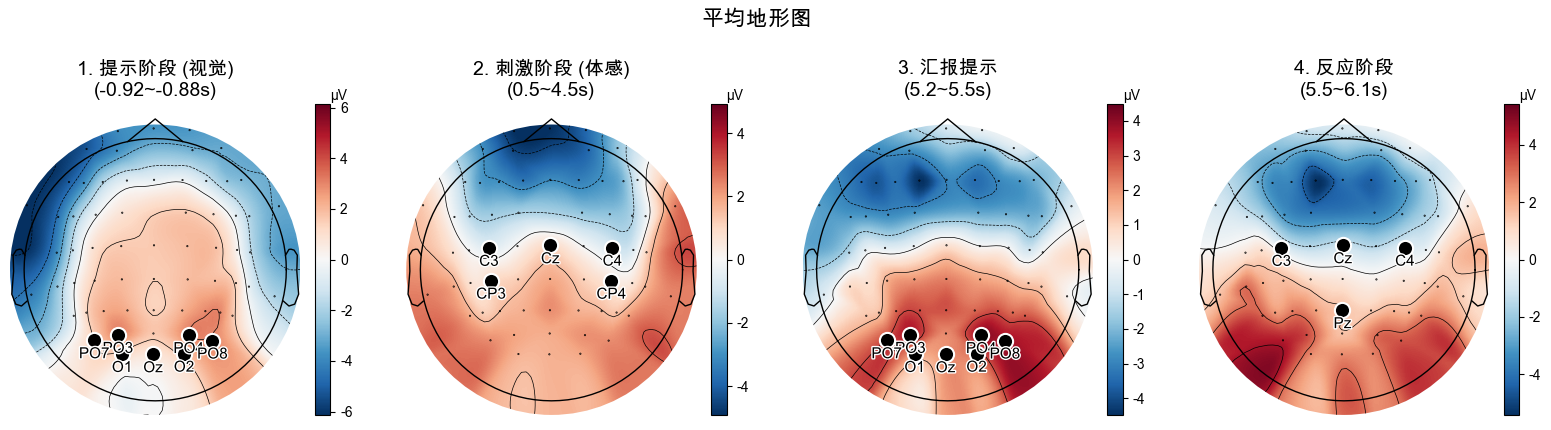

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# 设置绘图风格
# plt.rcParams['font.sans-serif'] = ['Arial']
# plt.rcParams['axes.unicode_minus'] = False 

# 解决 macOS 下中文显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# =========================================================================
# 【关键参数修改区】请在这里根据你的波形图 (Butterfly Plot) 来调整时间窗
# =========================================================================
phases_config = {
    "1. 提示阶段 (视觉)": {
        # 建议对照 Grand Average 波形图，找枕叶 (Oz) 偏离基线最明显的那个“鼓包”的时间段
        "time": (-0.92, -0.88), # 试着缩短一点，避开眨眼
        "highlight_chs": ['O1', 'O2', 'Oz', 'PO3', 'PO4', 'PO7', 'PO8'] 
    },
    "2. 刺激阶段 (体感)": {
        # SSSEP 是稳态诱发，通常整个刺激段都有，但也可能前几百毫秒最强
        "time": (0.5, 4.5),   
        "highlight_chs": ['C3', 'C4', 'Cz', 'CP3', 'CP4'] 
    },
    "3. 汇报提示": {
        # 汇报提示出现后的视觉处理阶段
        "time": (5.2, 5.5),   
        "highlight_chs": ['O1', 'O2', 'Oz', 'PO3', 'PO4', 'PO7', 'PO8'] 
    },
    "4. 反应阶段": {
        # 按键反应通常在 6秒左右，反应越快时间越早
        "time": (5.5, 6.1),   
        "highlight_chs": ['C3', 'C4', 'Cz', 'FCz', 'Pz'] 
    }
}
# =========================================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("平均地形图", fontsize=16, y=1.05)

# 获取传感器位置
pos = mne.channels.layout._find_topomap_coords(grand_average.info, None)
ch_names = grand_average.ch_names
xy = pos  # 后面 scatter 用

for i, (name, config) in enumerate(phases_config.items()):
    ax = axes[i]
    tmin, tmax = config["time"]
    target_chs = config["highlight_chs"]
    
    # 1. 抓取数据并计算平均
    real_tmax = min(tmax, grand_average.times[-1])
    evoked_crop = grand_average.copy().crop(tmin=tmin, tmax=real_tmax)
    mean_data = np.mean(evoked_crop.data, axis=1) * 1e6 
    
    # 2. 颜色范围
    limit = np.max(np.abs(mean_data))
    if limit < 0.5: limit = 0.5

    # 3. 绘图 (注意：这里把 mask 去了，防止 MNE 乱画线)
    im, _ = mne.viz.plot_topomap(
        mean_data, 
        grand_average.info, 
        axes=ax, 
        show=False,
        cmap='RdBu_r', 
        vlim=(-limit, limit),
        sensors=True, # 画背景小细点
        # mask=None   # 彻底关掉 mask 功能
    )
    
    # 4. 【完全手动画点】确保没有连线，且点够大
    # 找到要高亮的通道索引
    target_indices = [ch_names.index(ch) for ch in target_chs if ch in ch_names]
    
    # 提取这些点的坐标
    target_xs = xy[target_indices, 0]
    target_ys = xy[target_indices, 1]
    
    # 绘制实心大黑点
    # s=100 控制点的大小 (之前是 20-30 左右)
    ax.scatter(target_xs, target_ys, s=120, c='black', edgecolors='white', linewidth=1.5, zorder=10)
    
    # 5. 标字
    for idx in target_indices:
        ch_name = ch_names[idx]
        x, y = xy[idx]
        # 字体稍微往下挪一点，避开大点
        ax.text(x, y-0.005, ch_name, color='black', ha='center', va='top', fontsize=11, fontweight='bold',
                zorder=12,  # 关键：让字在图层最上层
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])

    ax.set_title(f"{name}\n({tmin}~{tmax}s)", fontsize=14)
    # --- 修改处：在 colorbar 上加单位 ---
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('µV', fontsize=10, rotation=0, labelpad=-10, y=1.05) # 把单位标在colorbar顶端

plt.tight_layout()
plt.show()

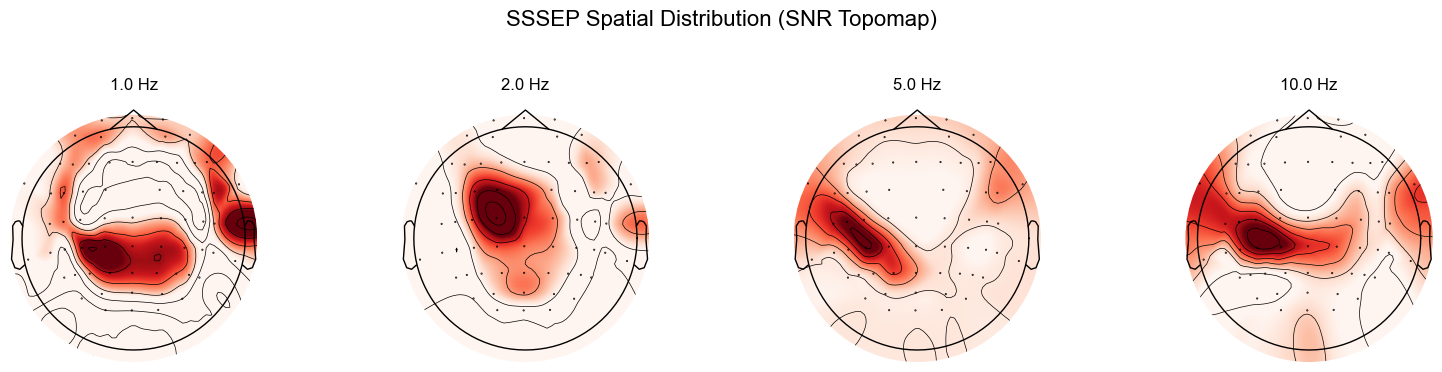

In [18]:
# ----------------- 单独保留：SSSEP 频域响应分布 (SNR Topomap) -----------------
# 这张图是对“Stimulation (0.5~4.5s)” 阶段最好的补充，展示大脑对频率的跟随响应
import matplotlib.pyplot as plt
import numpy as np
import mne

freqs_interest = [1.0, 2.0, 5.0, 10.0]

# 计算全通道 PSD (保留 spatial info)
psd_spatial = grand_average.compute_psd(
    method='welch', 
    fmin=0.5, fmax=15.0, 
    n_fft=2000, 
    picks='all',
    verbose=False
)
data_psd, freqs_psd = psd_spatial.get_data(return_freqs=True)

fig2, ax2 = plt.subplots(1, 4, figsize=(16, 3.5))
fig2.suptitle("SSSEP Spatial Distribution (SNR Topomap)", fontsize=16, y=1.05)

for i, f_target in enumerate(freqs_interest):
    # 找到最近的频率索引
    f_idx = np.argmin(np.abs(freqs_psd - f_target))
    
    # 简单的 SNR 计算：目标点能量 / (左边邻居 + 右边邻居)
    f_base_1 = np.argmin(np.abs(freqs_psd - (f_target - 0.5)))
    f_base_2 = np.argmin(np.abs(freqs_psd - (f_target + 0.5)))
    
    # 只要分母不为0
    baseline = (data_psd[:, f_base_1] + data_psd[:, f_base_2]) / 2
    snr_topo = data_psd[:, f_idx] / baseline
    
    # 绘制 Topomap
    mne.viz.plot_topomap(
        snr_topo, 
        grand_average.info, 
        axes=ax2[i], 
        show=False, 
        cmap='Reds',
        vlim=(1.0, np.percentile(snr_topo, 98))
    )
    ax2[i].set_title(f"{f_target} Hz")

plt.tight_layout()
plt.show()